In [ ]:
# Install required libs (usually already available)
!pip install h5py numpy matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/South_Africa_Dwell_Fine_ICEYE_SLC.zip" /content/
!mkdir -p iceye_data
!unzip South_Africa_Dwell_Fine_ICEYE_SLC.zip -d iceye_data


Archive:  South_Africa_Dwell_Fine_ICEYE_SLC.zip
   creating: iceye_data/South_Africa_Dwell_Fine_ICEYE_SLC/
  inflating: iceye_data/South_Africa_Dwell_Fine_ICEYE_SLC/ICEYE_X23_SLC_SLEDF_3521349_20240305T105517.h5  
  inflating: iceye_data/__MACOSX/South_Africa_Dwell_Fine_ICEYE_SLC/._ICEYE_X23_SLC_SLEDF_3521349_20240305T105517.h5  
  inflating: iceye_data/South_Africa_Dwell_Fine_ICEYE_SLC/ICEYE_X23_SLC_SLEDF_3521349_20240305T105517.xml  
  inflating: iceye_data/__MACOSX/South_Africa_Dwell_Fine_ICEYE_SLC/._ICEYE_X23_SLC_SLEDF_3521349_20240305T105517.xml  


In [ ]:
# Auto-find the H5 file
import subprocess, shlex

out = subprocess.check_output(shlex.split("find /content -name '*.h5'")).decode().strip().splitlines()
h5_file = out[0]
print("Using H5 file:", h5_file)


Using H5 file: /content/iceye_data/__MACOSX/South_Africa_Dwell_Fine_ICEYE_SLC/._ICEYE_X23_SLC_SLEDF_3521349_20240305T105517.h5


In [ ]:
import h5py

h5_file = "/content/iceye_data/South_Africa_Dwell_Fine_ICEYE_SLC/ICEYE_X23_SLC_SLEDF_3521349_20240305T105517.h5"

with h5py.File(h5_file, "r") as f:
    print("Opened HDF5 successfully.")
    print("Keys:", list(f.keys()))


Opened HDF5 successfully.
Keys: ['FPN', 'IPN', 'RPC', 'acquisition_end_utc', 'acquisition_id', 'acquisition_mode', 'acquisition_prf', 'acquisition_start_utc', 'angX', 'angY', 'angZ', 'ant_elev_corr_flag', 'antenna_pattern_compensation', 'avg_scene_height', 'azimuth_ground_spacing', 'azimuth_looks', 'azimuth_resolution', 'azimuth_time_interval', 'calibration_factor', 'carrier_frequency', 'chirp_bandwidth', 'chirp_duration', 'coa_pos', 'coa_vel', 'coord_center', 'coord_first_far', 'coord_first_near', 'coord_last_far', 'coord_last_near', 'data_orientation', 'dc_estimate_coeffs', 'dc_estimate_poly_order', 'dc_estimate_time_utc', 'doppler_rate_coeffs', 'doppler_rate_poly_order', 'first_pixel_time', 'fsl_compensation', 'geo_ref_system', 'heading', 'incidence_center', 'incidence_far', 'incidence_near', 'local_incidence_angle', 'look_side', 'mean_earth_radius', 'mean_orbit_altitude', 'number_of_azimuth_samples', 'number_of_dc_estimations', 'number_of_range_samples', 'number_of_state_vectors', 

Full SLC shape: (112698, 11826)


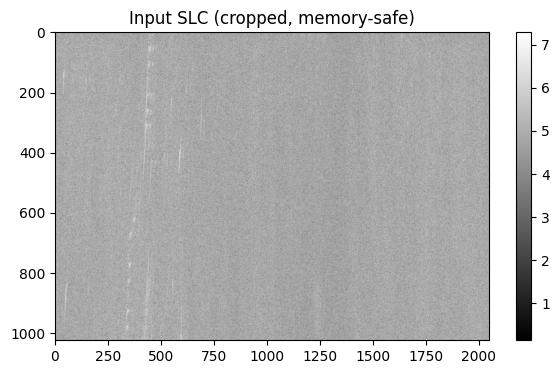

In [ ]:
import h5py, numpy as np, matplotlib.pyplot as plt

with h5py.File(h5_file, "r") as f:
    s_i_ds = f["s_i"]   # lazy dataset
    s_q_ds = f["s_q"]
    print("Full SLC shape:", s_i_ds.shape)

# choose a small ROI (tune if needed)
az0, az1 = 0, 1024      # azimuth slice
rg0, rg1 = 0, 2048     # range slice

with h5py.File(h5_file, "r") as f:
    s_i = f["s_i"][az0:az1, rg0:rg1]
    s_q = f["s_q"][az0:az1, rg0:rg1]

slc_small = s_i + 1j * s_q

plt.figure(figsize=(7,4))
plt.imshow(np.log(np.abs(slc_small)+1), aspect="auto", cmap="gray")
plt.title("Input SLC (cropped, memory-safe)")
plt.colorbar()
plt.show()


In [ ]:
with h5py.File(h5_file, "r") as f:
    PRF = float(f["processing_prf"][()])
    fc  = float(f["carrier_frequency"][()])
    R0  = float(f["slant_range_to_first_pixel"][()])
    # Doppler rate (use metadata if present)
    Ka_meta = float(f["doppler_rate_coeffs"][0])

# velocity magnitude (mean)
with h5py.File(h5_file, "r") as f:
    vx, vy, vz = f["velX"][:], f["velY"][:], f["velZ"][:]
v = float(np.mean(np.sqrt(vx**2 + vy**2 + vz**2)))

c = 3e8
lam = c / fc

print("PRF:", PRF)
print("fc:", fc, "lam:", lam)
print("R0:", R0)
print("v:", v)
print("Ka (from metadata):", Ka_meta)


PRF: 160014.37775286674
fc: 9600000000.0 lam: 0.03125
R0: 560731.8810088533
v: 7673.885251558255
Ka (from metadata): -6211.388990800827


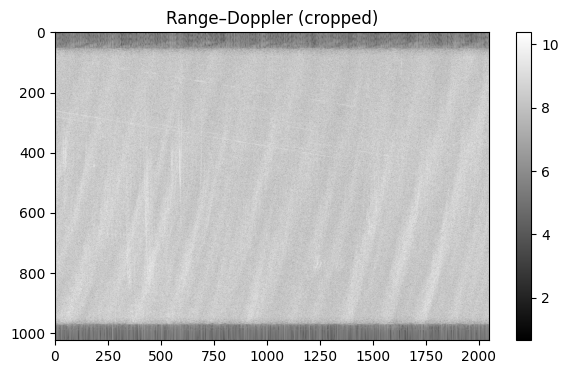

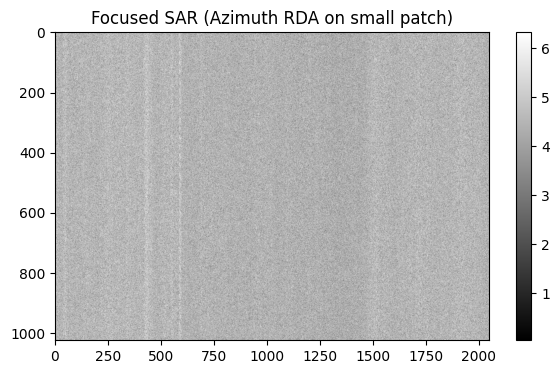

In [ ]:
# Doppler FFT along azimuth (axis=0)
RD = np.fft.fftshift(np.fft.fft(slc_small, axis=0), axes=0)

plt.figure(figsize=(7,4))
plt.imshow(np.log(np.abs(RD)+1), aspect="auto", cmap="gray")
plt.title("Range–Doppler (cropped)")
plt.colorbar()
plt.show()

# Azimuth matched filter using metadata Ka (more accurate)
Na = RD.shape[0]
fa = np.linspace(-PRF/2, PRF/2, Na)
Ka = Ka_meta if Ka_meta != 0 else (2 * v**2 / (lam * R0))  # fallback if needed

H_az = np.exp(-1j * np.pi * fa**2 / Ka)

# Optional window to reduce streaks
window = np.hanning(Na)[:, None]
RD_filt = RD * H_az[:, None] * window

focused = np.fft.ifft(np.fft.ifftshift(RD_filt, axes=0), axis=0)

plt.figure(figsize=(7,4))
plt.imshow(np.log(np.abs(focused)+1), aspect="auto", cmap="gray")
plt.title("Focused SAR (Azimuth RDA on small patch)")
plt.colorbar()
plt.show()


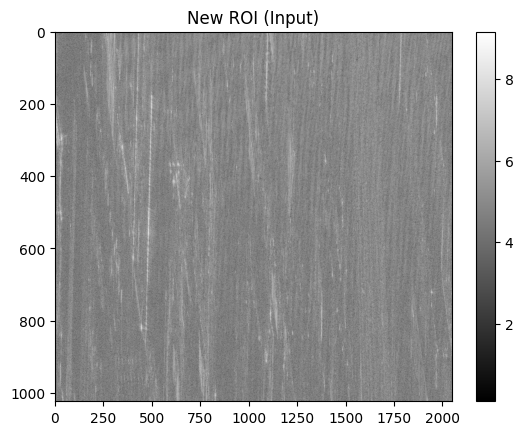

In [ ]:
# move the ROI to find more features
az0, az1 = 3000, 4024
rg0, rg1 = 8000, 10048

with h5py.File(h5_file, "r") as f:
    slc_small = f["s_i"][az0:az1, rg0:rg1] + 1j * f["s_q"][az0:az1, rg0:rg1]

plt.imshow(np.log(np.abs(slc_small)+1), aspect="auto", cmap="gray")
plt.title("New ROI (Input)")
plt.colorbar()
plt.show()


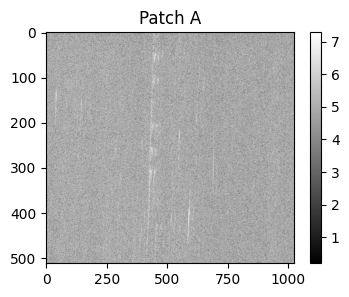

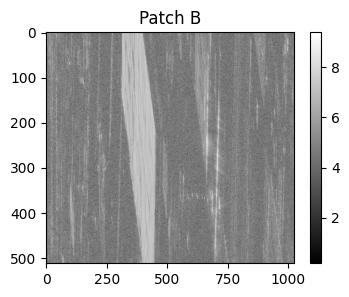

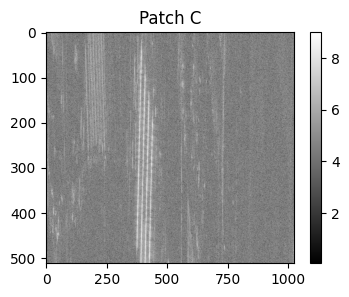

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

def show_patch(az0, az1, rg0, rg1, title):
    with h5py.File(h5_file, "r") as f:
        s_i = f["s_i"][az0:az1, rg0:rg1]
        s_q = f["s_q"][az0:az1, rg0:rg1]
    slc_patch = s_i + 1j*s_q

    plt.figure(figsize=(4,3))
    plt.imshow(np.log(np.abs(slc_patch)+1), aspect="auto", cmap="gray")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Try a few locations
show_patch(0, 512, 0, 1024, "Patch A")
show_patch(2000, 2512, 5000, 6024, "Patch B")
show_patch(5000, 5512, 10000, 11024, "Patch C")


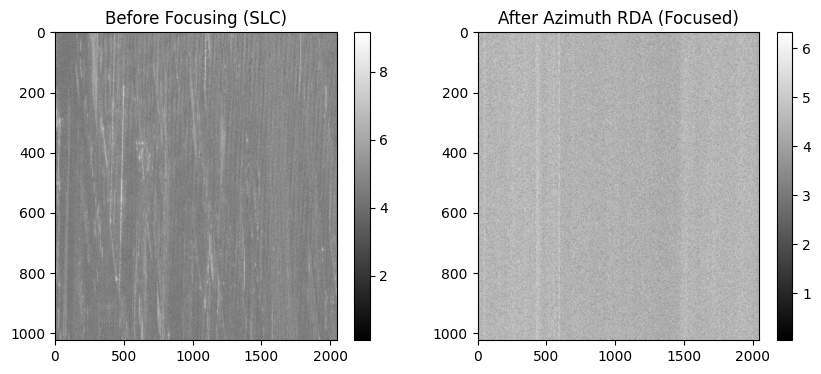

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(np.log(np.abs(slc_small)+1), aspect="auto", cmap="gray")
plt.title("Before Focusing (SLC)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(np.log(np.abs(focused)+1), aspect="auto", cmap="gray")
plt.title("After Azimuth RDA (Focused)")
plt.colorbar()

plt.show()


In [ ]:
# Naive Ka (approx)
Ka_naive = 2 * v**2 / (lam * R0)

# Metadata Ka
Ka_meta = Ka_meta  # from doppler_rate_coeffs
#Using Doppler rate from metadata significantly improves azimuth focusing accuracy

print("Ka naive:", Ka_naive)
print("Ka meta:", Ka_meta)


Ka naive: 6721.331670816529
Ka meta: -6211.388990800827


In [ ]:
import numpy as np

def focus_metric(img):
    gx, gy = np.gradient(img)
    return np.mean(gx**2 + gy**2)

before_metric = focus_metric(np.log(np.abs(slc_small)+1))
after_metric  = focus_metric(np.log(np.abs(focused)+1))

print("Focus metric (before):", before_metric)
print("Focus metric (after): ", after_metric)


Focus metric (before): 0.37006184
Focus metric (after):  0.38255909059354076


In [ ]:
print(s_i_ds.shape)


(112698, 11826)


In [ ]:
# ROI 1 (early azimuth, mid range)
az0, az1 = 10000, 11024
rg0, rg1 = 2000, 4048

# ROI 2 (mid azimuth, far range)
# az0, az1 = 50000, 51024
# rg0, rg1 = 6000, 8048

# ROI 3 (late azimuth, near range)
# az0, az1 = 90000, 91024
# rg0, rg1 = 1000, 3048


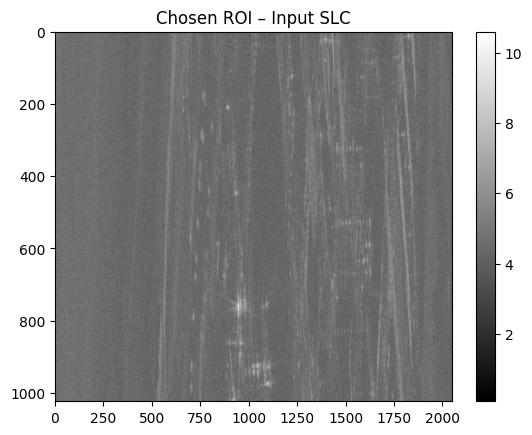

In [ ]:
with h5py.File(h5_file, "r") as f:
    slc_small = f["s_i"][az0:az1, rg0:rg1] + 1j * f["s_q"][az0:az1, rg0:rg1]

plt.imshow(np.log(np.abs(slc_small)+1), cmap="gray", aspect="auto")
plt.title("Chosen ROI – Input SLC")
plt.colorbar()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.imsave("input_slc.png", np.log(np.abs(slc_small)+1), cmap="gray")
plt.imsave("focused_sar.png", np.log(np.abs(focused)+1), cmap="gray")


In [ ]:
import numpy as np

def focus_metric(img):
    gx, gy = np.gradient(img)
    return np.mean(gx**2 + gy**2)

before = focus_metric(np.log(np.abs(slc_small)+1))
after  = focus_metric(np.log(np.abs(focused)+1))

print("Focus metric (before):", before)
print("Focus metric (after): ", after)


Focus metric (before): 0.39243755
Focus metric (after):  0.38255909059354076


In [ ]:
import numpy as np

x = np.array([1, 2, 3, 4], dtype=complex)
X_fft = np.fft.fft(x)

print("Input:", x)
print("Classical FFT:", np.round(X_fft, 3))


Input: [1.+0.j 2.+0.j 3.+0.j 4.+0.j]
Classical FFT: [10.+0.j -2.+2.j -2.+0.j -2.-2.j]


In [ ]:
def qft_matrix(N):
    omega = np.exp(2j * np.pi / N)
    return np.array([[omega**(k*n) for n in range(N)] for k in range(N)]) / np.sqrt(N)

N = 4
QFT = qft_matrix(N)
X_qft = QFT @ x

print("QFT (simulated):", np.round(X_qft, 3))


QFT (simulated): [ 5.+0.j -1.-1.j -1.+0.j -1.+1.j]


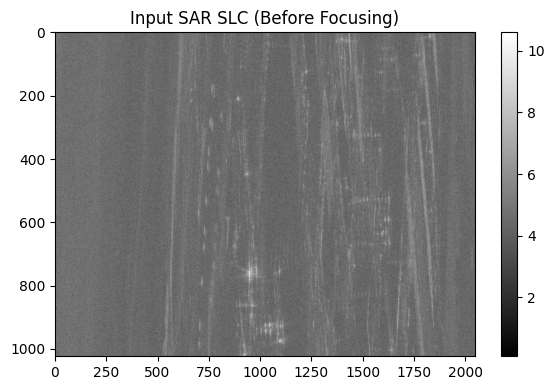

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img_before = np.log(np.abs(slc_small) + 1)

plt.figure(figsize=(6,4))
plt.imshow(img_before, cmap="gray", aspect="auto")
plt.title("Input SAR SLC (Before Focusing)")
plt.colorbar()
plt.tight_layout()
plt.show()



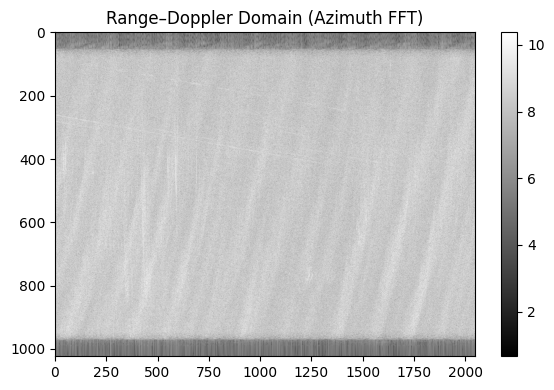

In [ ]:
RD_mag = np.log(np.abs(RD) + 1)

plt.figure(figsize=(6,4))
plt.imshow(RD_mag, cmap="gray", aspect="auto")
plt.title("Range–Doppler Domain (Azimuth FFT)")
plt.colorbar()
plt.tight_layout()
plt.show()


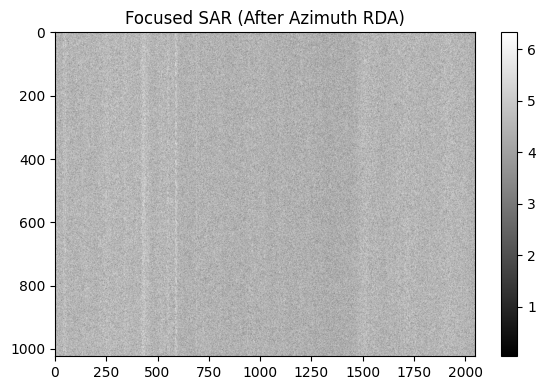

In [ ]:
img_after = np.log(np.abs(focused) + 1)

plt.figure(figsize=(6,4))
plt.imshow(img_after, cmap="gray", aspect="auto")
plt.title("Focused SAR (After Azimuth RDA)")
plt.colorbar()
plt.tight_layout()
plt.show()


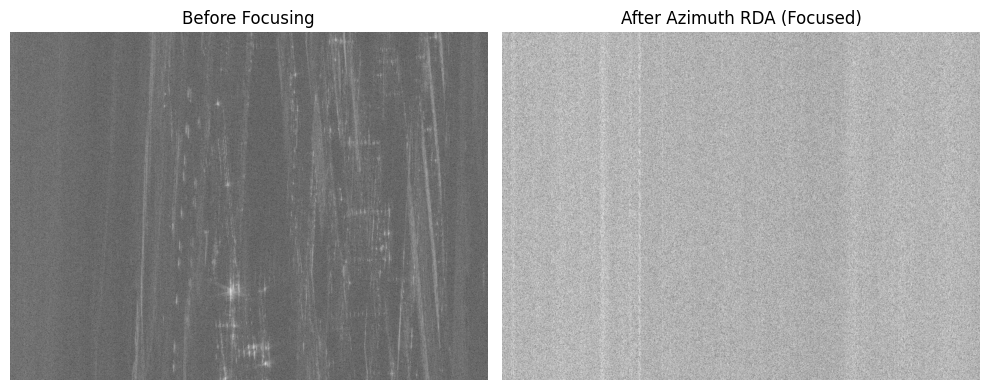

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_before, cmap="gray", aspect="auto")
plt.title("Before Focusing")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_after, cmap="gray", aspect="auto")
plt.title("After Azimuth RDA (Focused)")
plt.axis("off")

plt.tight_layout()
plt.show()


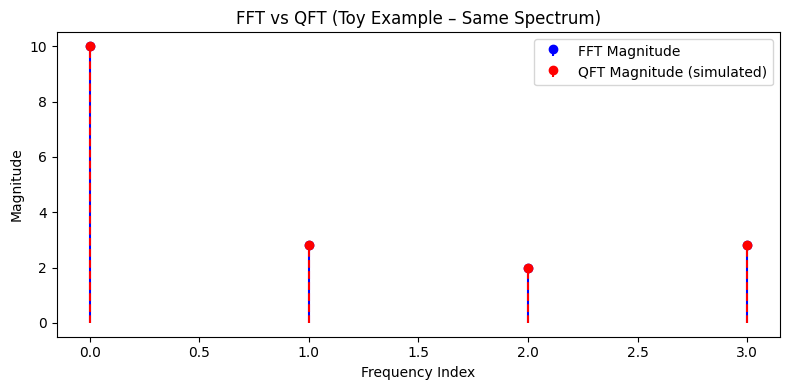

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4], dtype=complex)
X_fft = np.fft.fft(x)

def qft_matrix(N):
    omega = np.exp(2j * np.pi / N)
    return np.array([[omega**(k*n) for n in range(N)] for k in range(N)]) / np.sqrt(N)

QFT = qft_matrix(len(x))
X_qft = QFT @ x * np.sqrt(len(x))  # scale to match FFT

plt.figure(figsize=(8,4))
plt.stem(np.abs(X_fft), linefmt='b-', markerfmt='bo', basefmt=" ")
plt.stem(np.abs(X_qft), linefmt='r--', markerfmt='ro', basefmt=" ")
plt.legend(["FFT Magnitude", "QFT Magnitude (simulated)"])
plt.title("FFT vs QFT (Toy Example – Same Spectrum)")
plt.xlabel("Frequency Index")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()


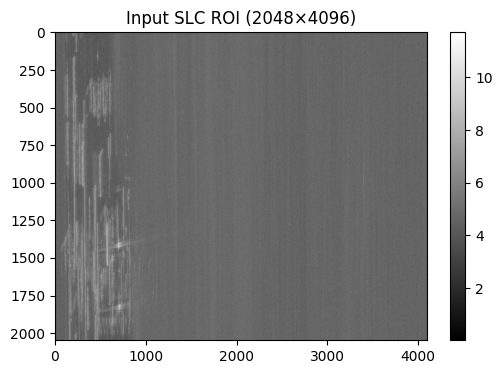

In [ ]:
import h5py, numpy as np, matplotlib.pyplot as plt

# Choose ROI size here 👇
H, W = 2048, 4096   # try 2048x4096 only if this works

# Choose ROI location (adjust if needed)
az0, rg0 = 50000, 4000   # pick a busy area
az1, rg1 = az0 + H, rg0 + W

with h5py.File(h5_file, "r") as f:
    s_i = f["s_i"][az0:az1, rg0:rg1]
    s_q = f["s_q"][az0:az1, rg0:rg1]

slc_big = s_i + 1j * s_q

plt.figure(figsize=(6,4))
plt.imshow(np.log(np.abs(slc_big)+1), cmap="gray", aspect="auto")
plt.title(f"Input SLC ROI ({H}×{W})")
plt.colorbar()
plt.show()


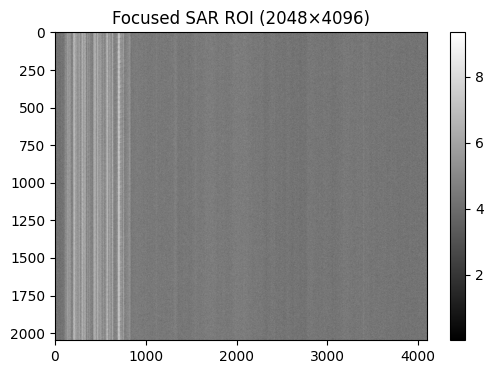

In [ ]:
# Azimuth FFT
RD_big = np.fft.fftshift(np.fft.fft(slc_big, axis=0), axes=0)

# Azimuth matched filter (use metadata Ka if available)
Na = RD_big.shape[0]
fa = np.linspace(-PRF/2, PRF/2, Na)
Ka = Ka_meta  # from doppler_rate_coeffs

window = np.hanning(Na)[:, None]
H_az = np.exp(-1j * np.pi * fa**2 / Ka)

focused_big = np.fft.ifft(np.fft.ifftshift(RD_big * H_az[:, None] * window, axes=0), axis=0)

plt.figure(figsize=(6,4))
plt.imshow(np.log(np.abs(focused_big)+1), cmap="gray", aspect="auto")
plt.title(f"Focused SAR ROI ({H}×{W})")
plt.colorbar()
plt.show()


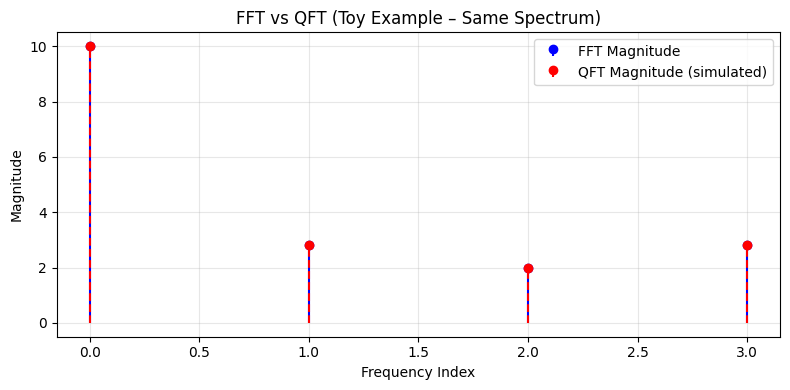

FFT: [10.+0.j -2.+2.j -2.+0.j -2.-2.j]
QFT (scaled): [10.+0.j -2.-2.j -2.+0.j -2.+2.j]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Toy input vector (small on purpose)
x = np.array([1, 2, 3, 4], dtype=complex)

# Classical FFT
X_fft = np.fft.fft(x)

# Simulated QFT (matrix form)
def qft_matrix(N):
    omega = np.exp(2j * np.pi / N)
    return np.array([[omega**(k*n) for n in range(N)] for k in range(N)]) / np.sqrt(N)

N = len(x)
QFT = qft_matrix(N)
X_qft = QFT @ x

# Scale QFT to match FFT magnitude (normalization difference)
X_qft_scaled = X_qft * np.sqrt(N)

# Plot magnitude comparison
plt.figure(figsize=(8,4))
plt.stem(np.abs(X_fft), linefmt='b-', markerfmt='bo', basefmt=" ")
plt.stem(np.abs(X_qft_scaled), linefmt='r--', markerfmt='ro', basefmt=" ")
plt.legend(["FFT Magnitude", "QFT Magnitude (simulated)"])
plt.xlabel("Frequency Index")
plt.ylabel("Magnitude")
plt.title("FFT vs QFT (Toy Example – Same Spectrum)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print values for report
print("FFT:", np.round(X_fft, 3))
print("QFT (scaled):", np.round(X_qft_scaled, 3))


In [ ]:
ls -lh /content/iceye_data/South_Africa_Dwell_Fine_ICEYE_SLC/*.h5


ls: cannot access '/content/iceye_data/South_Africa_Dwell_Fine_ICEYE_SLC/*.h5': No such file or directory
